# TCCT S82 — Blind Local-Mediator Counterfactual Test

第一格冻结 S81 前的模型架构与哈希；第二格才定义此前未见的局部干预并锁定协议；第三格首次运行 8 对孪生世界。

每次干预只修改查询分支的 3 条语义路由边（移除 3、加入 3），其余三个分支保持事实状态。反事实混合世界不等于旧的完整 Stop 模板，同时保持节点、边数和逐节点度数不变。模型输入不含目标标签。


Dataset[{<|Stage -> S82, Name -> BlindLocalMediatorCounterfactualTest, 
 
>     ArchitectureFrozenBeforeInterventionDefinition -> True, 
 
>     FrozenModelHash -> 
 
>      d6477c370436d09cf3e8cfc8530decd13ebf8bb79120362146ecb419f9d6a6c4, 
 
>     MinimalKernelHash -> 
 
>      ec291466f20922dc4b2b879853cd3879c37151fb7e96c34eff45dcb185fe7f34, 
 
>     CanonicalizerImplementationHash -> 
 
>      5e95c90f528a68d1045048e54b5a08809bf54c01b934902faf47f3dc3e5e587d, 
 
>     FrozenArchitectureHash -> 
 
>      47c0f2de12d2b8d1d0311f7a0fecacba782ff9f0b391b3c86631fdb569a8a3b7, 
 
>     NeutralControlTopologyHash -> 
 
>      01af33358afe3fcfe876288b6de7c99a89af22599320fec75911661e240bc121, 
 
>     PriorS81ProtocolHash -> 
 
>      b52a02dba0886b9252ced6d418a084a3f53cc33d9ef514706722013f2ff8bd71, 
 
>     PriorS81ResultHash -> 
 
>      e9f2653325a5f4a024c1b3a3678c94eba24532d1ab9461569c2a9b7a2f9190d7, 
 
>     HistoricalRegressionRerun -> False, S81PairAuditRerun -> False, 
 
>     TrainingRun -> False, CandidateSearchRun -> False, PolicyEditApplied -> False, 
 
>     RetuningApplied -> False, FreezePreflightPassed -> True|>}, 
 
>   TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`AnyType, 17], 
 
>    1], <||>]
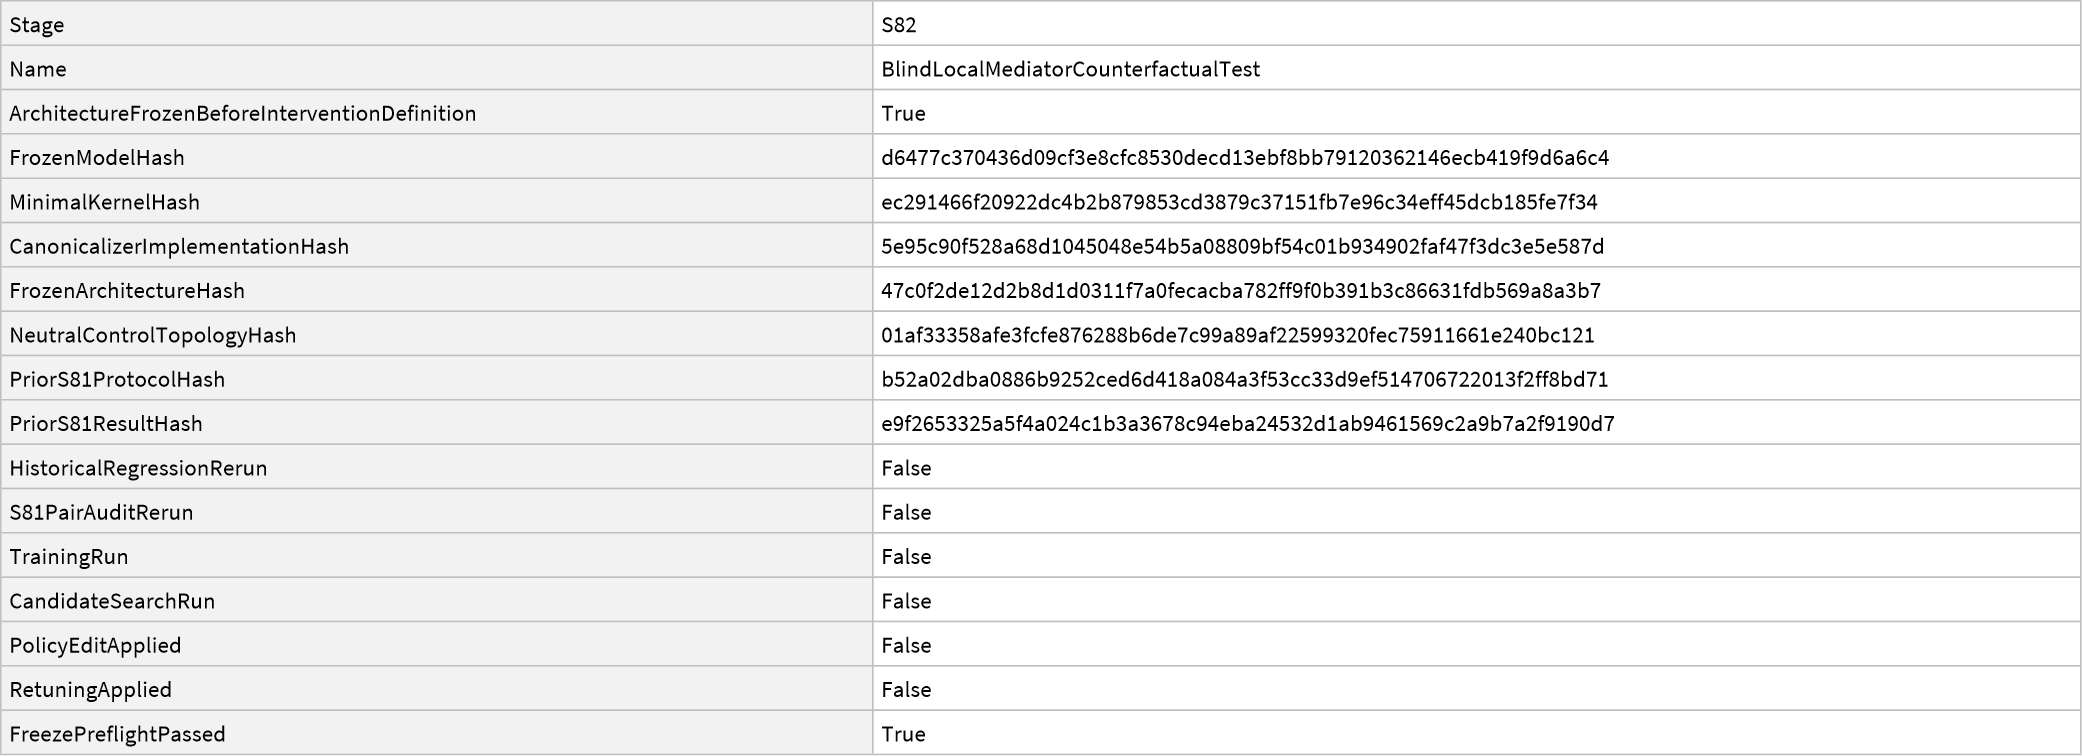

In [117]:




ClearAll["Global`*"];
$HistoryLength=0;

expectedFrozenModelHash79A=
"d6477c370436d09cf3e8cfc8530decd13ebf8bb79120362146ecb419f9d6a6c4";
expectedTopologySpecHash79A=
"b108aa7f2c59c395056fb9124e7d5d9074e39e5e124d0d98011800433e0dd95b";
expectedTopologyImplementationHash79A=
"f27d1ce683317d35a5e9da01536d95c706065810c27462e336cdb76f4a2dab52";
expectedS79BlindResultHash79A=
"b1ebf089e43121a61d4181139d4ba0a8970dc646a7a41425f861cff2e1f8461d";

frozen75D=<|
"Stage"->"S75D",
"Name"->"ValidatedPolicyCompletion",
"Representation"->
"PairedRadius2Radius3WithParentChildCardinality",
"Params"->{-1,0,-1,-1,-1,0,1,-1},
"K"->5,
"TrainingPolicy"->{{3,1},{3,3},{4,3}},
"Policy"->{
{1,3},{2,2},{3,1},{3,2},{3,3},{4,3}
},
"AddedContinueCodes"->{{1,3},{2,2},{3,2}},
"PolicyCompletionUsesValidationLabels"->True,
"FrozenBeforeS76"->True
|>;

P59[a_,b_,n_Integer,s_Integer]:=If[
n<=0,
{DirectedEdge[a,b]},
DirectedEdge@@@Partition[
Join[{a},Range[s,s+n-1],{b}],
2,
1
]
];

A59[t_,fan_Integer,s_Integer]:=Module[{p1,p2,ls},
p1=s+1;
p2=s+2;
ls=Range[s+3,s+2+fan];
Join[
{
DirectedEdge[p2,p1],
DirectedEdge[p1,t]
},
Table[
DirectedEdge[ls[[i]],p2],
{i,Length[ls]}
]
]
];

T59[d_Integer,r_String,a_Integer,seed_Integer]:=Module[
{
bb,K,c,v,q,e,f={},ib,m,safe,u,dum,r1,r2,wrong,
main,perm,anc,i
},
bb=1000000000 seed;
K=bb+1;
c=Table[bb+100+i,{i,4}];
v=Table[bb+200+i,{i,4}];
q=Table[bb+300+i,{i,4}];
e=Flatten[
Table[
{
DirectedEdge[K,c[[i]]],
DirectedEdge[c[[i]],v[[i]]]
},
{i,4}
],
1
];
Do[
ib=bb+20000000 i;
m=ib+1;
safe=ib+2;
u=ib+3;
dum=ib+4;
r1=ib+10;
r2=ib+20;
wrong=c[[1+Mod[i,4]]];
main=Join[
P59[q[[i]],r1,d,ib+1000000],
P59[q[[i]],r2,d,ib+2000000],
{
DirectedEdge[r1,m],
DirectedEdge[r2,m]
},
P59[q[[i]],safe,d+1,ib+3000000]
];
perm=If[
r==="Continue",
{
DirectedEdge[m,c[[i]]],
DirectedEdge[safe,dum],
DirectedEdge[u,wrong]
},
{
DirectedEdge[m,wrong],
DirectedEdge[safe,c[[i]]],
DirectedEdge[u,dum]
}
];
anc=Join[
A59[m,i,bb+970000000+10000 i],
A59[c[[i]],i,bb+980000000+10000 i]
];
e=Join[e,main,perm,anc];
AppendTo[f,m],
{i,4}
];
{{Union[e],q,K,v,c,f},a}
];

Case59[d_Integer,a_Integer,r_String]:=
T59[d,r,a,59000000+100 d+a];

rw60={-9,6,-2,-2,4,2,-2,6,0};

Pack60[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,v,pos,gi,go,pa,ch,id,od,
pin,pout,cin,cout},
e=x[[1]];
v=Union@Join[
Flatten[List@@@e],
x[[2]],
{x[[3]]},
x[[4]],
x[[5]],
x[[6]]
];
pos=AssociationThread[v,Range[Length[v]]];
gi=GroupBy[
Cases[e,DirectedEdge[u_,w_]:>{w,u}],
First->Last
];
go=GroupBy[
Cases[e,DirectedEdge[u_,w_]:>{u,w}],
First->Last
];
pa=(Lookup[pos,Lookup[gi,#,{}]]&)/@v;
ch=(Lookup[pos,Lookup[go,#,{}]]&)/@v;
id=Length/@pa;
od=Length/@ch;
pin=(Total[id[[#]]]&)/@pa;
pout=(Total[od[[#]]]&)/@pa;
cin=(Total[id[[#]]]&)/@ch;
cout=(Total[od[[#]]]&)/@ch;
{
pa,id,od,
Lookup[pos,x[[2,a]]],
Lookup[pos,x[[5]]],
a,
Length[v],
pin,pout,cin,cout,v
}
];

SigLevels61[c_List,rmax_Integer]:=Module[
{p,pa,id,od,n,ch,cur,nxt,levs,j,k,u},
p=Pack60[c];
pa=p[[1]];
id=p[[2]];
od=p[[3]];
n=p[[7]];
ch=Table[{},n];
Do[
Do[
If[u>0,ch[[u]]=Append[ch[[u]],j]],
{u,pa[[j]]}
],
{j,n}
];
cur=AssociationThread[
Range[n],
MapThread[List,{id,od}]
];
levs={cur};
Do[
nxt=AssociationThread[
Range[n],
Table[
{
Lookup[cur,j],
Sort[Lookup[cur,pa[[j]]]],
Sort[Lookup[cur,ch[[j]]]]
},
{j,n}
]
];
AppendTo[levs,nxt];
cur=nxt,
{k,rmax}
];
levs
];

PropagationSafetyCap78[c_List]:=Module[{n},
n=Pack60[c][[7]];
Max[64,2 n+8]
];

RejectTrace78[c_List]:=Module[
{
p,pa,id,od,q,n,pin,pout,cin,cout,h,z,h2,nz,j,k,
aps,ap,pz,o,zv,rf,rd,dd,pg,allow,active=0,
rej={},rounds=0,terminatedNaturally=False,safetyCap
},
p=Pack60[c];
pa=p[[1]];
id=p[[2]];
od=p[[3]];
q=p[[4]];
n=p[[7]];
pin=p[[8]];
pout=p[[9]];
cin=p[[10]];
cout=p[[11]];
safetyCap=Max[64,2 n+8];
h=ConstantArray[0,n];
z=ConstantArray[0,n];
h[[q]]=1;
For[
k=1,
k<=safetyCap,
k++,
rounds=k;
h2=ConstantArray[0,n];
nz=ConstantArray[0,n];
active=0;
Do[
aps=Select[
pa[[j]],
Function[u,u>0&&h[[u]]==1]
];
ap=Length[aps];
If[
ap>0,
pz=Max[z[[aps]]];
o=Boole[ap>1];
zv={0,1,2,1,3,1,3,1}[[1+2 pz+o]];
nz[[j]]=zv;
rf={
1,
Boole[zv>0],
zv,
Sign[pin[[j]]-id[[j]]],
Sign[pout[[j]]-id[[j]]],
Sign[cin[[j]]-id[[j]]],
Sign[cout[[j]]-od[[j]]],
Sign[id[[j]]-od[[j]]],
Sign[pout[[j]]-cin[[j]]]
};
rd=rw60.rf;
dd=1-cin[[j]]+2 cout[[j]];
pg=od[[j]]+2 Boole[zv>0]-zv;
If[rd>0&&dd<=0,AppendTo[rej,{k,j}]];
allow=If[rd>0,dd>0,pg>0];
If[
TrueQ[allow],
h2[[j]]=1;
active++
]
],
{j,n}
];
h=h2;
z=nz;
If[
active==0,
terminatedNaturally=True;
Break[]
]
];
<|
"Rejects"->rej,
"RoundsExecuted"->rounds,
"TerminatedNaturally"->terminatedNaturally,
"SafetyCap"->safetyCap,
"HitSafetyCap"->And[
!TrueQ[terminatedNaturally],
SameQ[rounds,safetyCap]
],
"ActiveAfterLastRound"->active,
"PackedNodeCount"->n
|>
];

DecisionStatePairsFromRejects78[c_List,rej_List]:=Module[
{levels,nodes},
If[Length[rej]==0,Return[{}]];
levels=SigLevels61[c,3];
nodes=rej[[All,2]];
DeleteDuplicates[
Map[
Function[node,
{
Lookup[levels[[3]],node],
Lookup[levels[[4]],node]
}
],
nodes
]
]
];

EncodeRows75[data_List,p_List,k_Integer]:=Module[{rec},
rec[s_]:=rec[s]=If[
MatchQ[s,{_Integer,_Integer}],
1+Mod[s[[1]]+2 s[[2]],k],
Module[
{z,ps,cs,parentSum,childSum,parentSquare,childSquare},
z=rec[s[[1]]];
ps=rec/@s[[2]];
cs=rec/@s[[3]];
parentSum=Total[ps-1];
childSum=Total[cs-1];
parentSquare=Total[(ps-1)^2];
childSquare=Total[(cs-1)^2];
1+Mod[
p[[1]]+
p[[2]](z-1)+
p[[3]]parentSum+
p[[4]]childSum+
p[[5]]parentSquare+
p[[6]]childSquare+
p[[7]]Length[ps]+
p[[8]]Length[cs],
k
]
]
];
Map[
Function[row,
Join[
KeyTake[row,{"Grammar","Depth","Answer","Target"}],
<|
"Codes"->DeleteDuplicates[
Map[
Function[pair,{rec[pair[[1]]],rec[pair[[2]]]}],
row["StatePairs"]
]
]
|>
]
],
data
]
];

DiamondIn72[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,rm,
add,s1,s2,g,i,j},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[new,DirectedEdge[u_,v_]/;v===m:>{u,v}];
rm=DirectedEdge@@@incs;
add={};
Do[
s1=next;
s2=next+1;
g=next+2;
next=next+3;
add=Join[
add,
{
DirectedEdge[incs[[j,1]],s1],
DirectedEdge[incs[[j,1]],s2],
DirectedEdge[s1,g],
DirectedEdge[s2,g],
DirectedEdge[g,m]
}
],
{j,Length[incs]}
];
new=Join[Complement[new,rm],add],
{i,Length[f]}
];
{{Union[new],x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]},a}
];

DoubleDiamondIn79[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,removed,
added,parent,s1,s2,g1,t1,t2,g2,i,j
},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[new,DirectedEdge[u_,v_]/;v===m:>{u,v}];
removed=DirectedEdge@@@incs;
added={};
Do[
parent=incs[[j,1]];
s1=next;
s2=next+1;
g1=next+2;
t1=next+3;
t2=next+4;
g2=next+5;
next=next+6;
added=Join[
added,
{
DirectedEdge[parent,s1],
DirectedEdge[parent,s2],
DirectedEdge[s1,g1],
DirectedEdge[s2,g1],
DirectedEdge[g1,t1],
DirectedEdge[g1,t2],
DirectedEdge[t1,g2],
DirectedEdge[t2,g2],
DirectedEdge[g2,m]
}
],
{j,Length[incs]}
];
new=Join[Complement[new,removed],added],
{i,Length[f]}
];
{{Union[new],x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]},a}
];

Case79[
depth_Integer,
answer_Integer,
target_String
]:=DoubleDiamondIn79[
Case59[depth,answer,target]
];

topologySpec79=<|
"Topology"->"DoubleDiamondIn",
"TransformationScope"->
"EveryIncomingEdgeOfEachDecisionNode",
"Motif"->"TwoSerialPrivateDiamonds",
"CrossParentSharing"->False,
"DiamondsPerOriginalIncomingEdge"->2,
"ParentToDecisionPathLength"->5,
"NewNodesPerOriginalIncomingEdge"->6,
"ReplacementEdgesPerOriginalIncomingEdge"->9,
"EdgeDeltaPerOriginalIncomingEdge"->8,
"ReachabilityPreserved"->True,
"OriginalDecisionNodesPreserved"->True,
"TopologyUsedInS59ThroughS78"->False
|>;

topologySpecHash79=Hash[
Normal[topologySpec79],
"SHA256",
"HexString"
];

topologyImplementationHash79=Hash[
{DownValues[DoubleDiamondIn79],DownValues[Case79]},
"SHA256",
"HexString"
];

modelHash79A=Hash[
Normal[frozen75D],
"SHA256",
"HexString"
];

minimalKernelHash79A=Hash[
{
DownValues[P59],
DownValues[A59],
DownValues[T59],
DownValues[Case59],
OwnValues[rw60],
DownValues[Pack60],
DownValues[SigLevels61],
DownValues[PropagationSafetyCap78],
DownValues[RejectTrace78],
DownValues[DecisionStatePairsFromRejects78],
DownValues[EncodeRows75],
DownValues[DiamondIn72],
DownValues[DoubleDiamondIn79],
DownValues[Case79]
},
"SHA256",
"HexString"
];


ClearAll[
FindPrivateDiamond79B,
CanonicalizePrivateDiamonds79B,
CanonicalCase79B,
CaseByTopology79B,
DecisionIncomingEdgeCount79B,
ExpectedContractions79B
];

FindPrivateDiamond79B[e_List,protected_List]:=Module[
{
vertices,parents,children,harvest,ins,outs,s1,s2,
p1,p2,g
},
vertices=Union@Flatten[List@@@e];
parents=GroupBy[
Cases[e,DirectedEdge[u_,v_]:>{v,u}],
First->Last
];
children=GroupBy[
Cases[e,DirectedEdge[u_,v_]:>{u,v}],
First->Last
];
harvest=Reap[
Do[
If[
!MemberQ[protected,g],
ins=Sort@Lookup[parents,g,{}];
outs=Sort@Lookup[children,g,{}];
If[
Length[ins]===2&&Length[outs]===1,
{s1,s2}=ins;
p1=Sort@Lookup[parents,s1,{}];
p2=Sort@Lookup[parents,s2,{}];
If[
And[
Intersection[protected,{s1,s2,g}]==={},
Length[p1]===1,
SameQ[p1,p2],
SameQ[Sort@Lookup[children,s1,{}],{g}],
SameQ[Sort@Lookup[children,s2,{}],{g}],
DuplicateFreeQ[{First[p1],s1,s2,g,First[outs]}]
],
Sow[{First[p1],s1,s2,g,First[outs]}]
]
]
],
{g,vertices}
]
][[2]];
If[
harvest==={},
Missing["NotFound"],
First@Sort@First[harvest]
]
];

CanonicalizePrivateDiamonds79B[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,protected,candidate,
parent,s1,s2,g,target,removed,count=0,log={}
},
e=Union[x[[1]]];
protected=Union[
x[[2]],
{x[[3]]},
x[[4]],
x[[5]],
x[[6]]
];
While[
True,
candidate=FindPrivateDiamond79B[e,protected];
If[MissingQ[candidate],Break[]];
{parent,s1,s2,g,target}=candidate;
removed={s1,s2,g};
e=Union[
Select[
e,
Function[edge,
And[
!MemberQ[removed,edge[[1]]],
!MemberQ[removed,edge[[2]]]
]
]
],
{DirectedEdge[parent,target]}
];
count++;
AppendTo[log,candidate]
];
<|
"Case"->{{
e,
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
},a},
"Contractions"->count,
"ContractionLog"->log,
"ProtectedNodesPreserved"->And@@Map[
MemberQ[Union@Flatten[List@@@e],#]&,
protected
]
|>
];

CanonicalCase79B[c_List]:=
CanonicalizePrivateDiamonds79B[c]["Case"];

CaseByTopology79B[
topology_String,
depth_Integer,
answer_Integer,
target_String
]:=Switch[
topology,
"Base",
Case59[depth,answer,target],
"DiamondIn",
DiamondIn72[Case59[depth,answer,target]],
"DoubleDiamondIn",
DoubleDiamondIn79[Case59[depth,answer,target]],
_,
$Failed
];

DecisionIncomingEdgeCount79B[c_List]:=Module[
{e=c[[1,1]],f=c[[1,6]]},
Total[Count[e,DirectedEdge[_,#]]&/@f]
];

ExpectedContractions79B[
topology_String,
baseCase_List
]:=Switch[
topology,
"Base",
0,
"DiamondIn",
DecisionIncomingEdgeCount79B[baseCase],
"DoubleDiamondIn",
2 DecisionIncomingEdgeCount79B[baseCase],
_,
Missing["UnknownTopology"]
];

canonicalizerImplementationHash79B=Hash[
{
DownValues[FindPrivateDiamond79B],
DownValues[CanonicalizePrivateDiamonds79B],
DownValues[CanonicalCase79B]
},
"SHA256",
"HexString"
];


ClearAll[HierarchicalDiamondIn80,Case80];

HierarchicalDiamondIn80[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,removed,
added,parent,s1,s2,g,l1,l2,lg,r1,r2,rg,i,j
},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[
new,
DirectedEdge[u_,v_]/;v===m:>{u,v}
];
removed=DirectedEdge@@@incs;
added={};
Do[
parent=incs[[j,1]];
s1=next;
s2=next+1;
g=next+2;
l1=next+3;
l2=next+4;
lg=next+5;
r1=next+6;
r2=next+7;
rg=next+8;
next=next+9;
added=Join[
added,
{
DirectedEdge[parent,l1],
DirectedEdge[parent,l2],
DirectedEdge[l1,lg],
DirectedEdge[l2,lg],
DirectedEdge[lg,s1],
DirectedEdge[parent,r1],
DirectedEdge[parent,r2],
DirectedEdge[r1,rg],
DirectedEdge[r2,rg],
DirectedEdge[rg,s2],
DirectedEdge[s1,g],
DirectedEdge[s2,g],
DirectedEdge[g,m]
}
],
{j,Length[incs]}
];
new=Join[
Complement[new,removed],
added
],
{i,Length[f]}
];
{{
Union[new],
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
},a}
];

Case80[
depth_Integer,
answer_Integer,
target_String
]:=HierarchicalDiamondIn80[
Case59[depth,answer,target]
];

topologySpec80=<|
"Topology"->"HierarchicalDiamondIn",
"TransformationScope"->
"EveryIncomingEdgeOfEachDecisionNode",
"Motif"->
"OuterDiamondWhoseTwoUpperBranchesArePrivateDiamonds",
"CrossParentSharing"->False,
"PrivateDiamondsPerOriginalIncomingEdge"->3,
"HierarchyLevels"->2,
"ParentToDecisionPathLength"->5,
"NewNodesPerOriginalIncomingEdge"->9,
"ReplacementEdgesPerOriginalIncomingEdge"->13,
"EdgeDeltaPerOriginalIncomingEdge"->12,
"ExpectedCanonicalContractionsPerOriginalEdge"->3,
"ReachabilityPreserved"->True,
"OriginalDecisionNodesPreserved"->True,
"PrimitivePrivateDiamondSeenBeforeS80"->True,
"HierarchicalCompositionSeenBeforeS80"->False,
"TopologyUsedBeforeS80"->False
|>;

topologySpecHash80=Hash[
Normal[topologySpec80],
"SHA256",
"HexString"
];

topologyImplementationHash80=Hash[
{
DownValues[HierarchicalDiamondIn80],
DownValues[Case80]
},
"SHA256",
"HexString"
];expectedMinimalKernelHash82=
"ec291466f20922dc4b2b879853cd3879c37151fb7e96c34eff45dcb185fe7f34";
expectedCanonicalizerHash82=
"5e95c90f528a68d1045048e54b5a08809bf54c01b934902faf47f3dc3e5e587d";
expectedFrozenArchitectureHash82=
"47c0f2de12d2b8d1d0311f7a0fecacba782ff9f0b391b3c86631fdb569a8a3b7";
expectedNeutralTopologyHash82=
"01af33358afe3fcfe876288b6de7c99a89af22599320fec75911661e240bc121";
expectedS81ProtocolHash82=
"b52a02dba0886b9252ced6d418a084a3f53cc33d9ef514706722013f2ff8bd71";
expectedS81ResultHash82=
"e9f2653325a5f4a024c1b3a3678c94eba24532d1ab9461569c2a9b7a2f9190d7";

frozenArchitectureHash82=Hash[
{
Normal[frozen75D],
minimalKernelHash79A,
canonicalizerImplementationHash79B
},
"SHA256",
"HexString"
];

freezePreflightPassed82=And[
SameQ[modelHash79A,expectedFrozenModelHash79A],
SameQ[
minimalKernelHash79A,
expectedMinimalKernelHash82
],
SameQ[
canonicalizerImplementationHash79B,
expectedCanonicalizerHash82
],
SameQ[
frozenArchitectureHash82,
expectedFrozenArchitectureHash82
],
SameQ[
topologyImplementationHash80,
expectedNeutralTopologyHash82
]
];

freezeCertificate82=<|
"Stage"->"S82",
"Name"->"BlindLocalMediatorCounterfactualTest",
"ArchitectureFrozenBeforeInterventionDefinition"->True,
"FrozenModelHash"->modelHash79A,
"MinimalKernelHash"->minimalKernelHash79A,
"CanonicalizerImplementationHash"->
canonicalizerImplementationHash79B,
"FrozenArchitectureHash"->frozenArchitectureHash82,
"NeutralControlTopologyHash"->
topologyImplementationHash80,
"PriorS81ProtocolHash"->expectedS81ProtocolHash82,
"PriorS81ResultHash"->expectedS81ResultHash82,
"HistoricalRegressionRerun"->False,
"S81PairAuditRerun"->False,
"TrainingRun"->False,
"CandidateSearchRun"->False,
"PolicyEditApplied"->False,
"RetuningApplied"->False,
"FreezePreflightPassed"->freezePreflightPassed82
|>;

If[
!TrueQ[freezePreflightPassed82],
Print[Dataset[{freezeCertificate82}]];
Print["S82 aborted before intervention definition: frozen architecture hash mismatch."];
Abort[]
];

Dataset[{freezeCertificate82}]


Dataset[{<|Stage -> S82, ProtocolHash -> 
 
>      7695bea7ea07f903615ce01ad6b6a8481d2741ef1ce08fafb0e2d279e39f09bd, 
 
>     Depths -> {31, 63}, ExpectedPairs -> 8, ExpectedWorldsEvaluated -> 16, 
 
>     Intervention -> QueriedBranchLocalSemanticRoutingToggle, 
 
>     InterventionTypeSeenBeforeS82 -> False, ExpectedEdgeEditDistancePerPair -> 6, 
 
>     InterventionImplementationHash -> 
 
>      45a4f2364a569f5346c9d007c0da716dc1752193fc68abcb2b6acd88c5af54bf, 
 
>     NoPairEvaluatedBeforeProtocolHash -> True, S82IsBlindCounterfactualTest -> True|>}\
 
>    , TypeSystem`Vector[TypeSystem`Struct[{Stage, ProtocolHash, Depths, ExpectedPairs, 
 
>      ExpectedWorldsEvaluated, Intervention, InterventionTypeSeenBeforeS82, 
 
>      ExpectedEdgeEditDistancePerPair, InterventionImplementationHash, 
 
>      NoPairEvaluatedBeforeProtocolHash, S82IsBlindCounterfactualTest}, 
 
>     {TypeSystem`Atom[String], TypeSystem`Atom[String], 
 
>      TypeSystem`Vector[TypeSystem`Atom[Integer], 2], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[String], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean]}], 1], <||>]
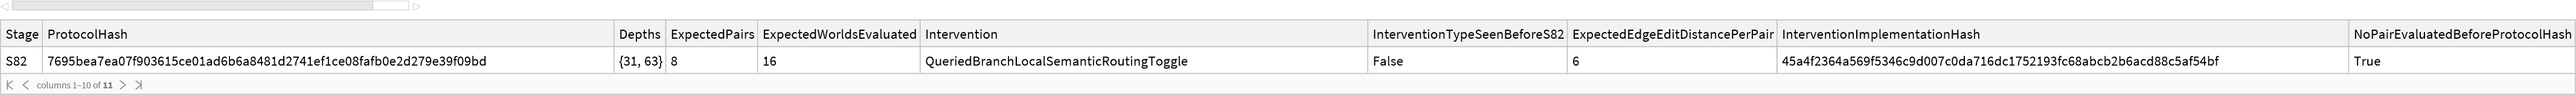

In [168]:

ClearAll[
EdgeSet81,
VertexSet81,
WithEdges81,
EdgePatch81,
ApplyEdgePatch81,
InverseEdgePatch81,
VertexDegreeProfile81,
OppositeAction81
];

EdgeSet81[c_List]:=c[[1,1]];

VertexSet81[c_List]:=Union@Flatten[
List@@@EdgeSet81[c]
];

WithEdges81[c_List,newEdges_List]:=Module[
{x=c[[1]],a=c[[2]]},
{{
Union[newEdges],
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
},a}
];

EdgePatch81[from_List,to_List]:=<|
"Remove"->Complement[
EdgeSet81[from],
EdgeSet81[to]
],
"Add"->Complement[
EdgeSet81[to],
EdgeSet81[from]
]
|>;

ApplyEdgePatch81[c_List,patch_Association]:=Module[
{e,remove,add,valid},
e=EdgeSet81[c];
remove=patch["Remove"];
add=patch["Add"];
valid=And[
And@@Map[MemberQ[e,#]&,remove],
And@@Map[!MemberQ[e,#]&,add],
Intersection[remove,add]==={}
];
If[
!TrueQ[valid],
Return[$Failed]
];
WithEdges81[
c,
Join[Complement[e,remove],add]
]
];

InverseEdgePatch81[patch_Association]:=<|
"Remove"->patch["Add"],
"Add"->patch["Remove"]
|>;

VertexDegreeProfile81[c_List]:=Module[
{e=EdgeSet81[c],vertices},
vertices=VertexSet81[c];
AssociationThread[
vertices,
Map[
Function[node,
{
Count[e,DirectedEdge[_,node]],
Count[e,DirectedEdge[node,_]]
}
],
vertices
]
]
];

OppositeAction81[action_String]:=Switch[
action,
"Continue","Stop",
"Stop","Continue",
_,Missing["UnknownAction"]
];ClearAll[
LocalMediatorSources82,
FullSemanticPatch82,
LocalMediatorPatch82,
PatchSourceSet82,
ReferenceAction82
];

LocalMediatorSources82[c_List]:=Module[
{x=c[[1]],answer=c[[2]],m},
m=x[[6,answer]];
{m,m+1,m+2}
];

FullSemanticPatch82[
depth_Integer,
answer_Integer
]:=EdgePatch81[
Case59[depth,answer,"Continue"],
Case59[depth,answer,"Stop"]
];

LocalMediatorPatch82[
depth_Integer,
answer_Integer
]:=Module[
{factual,fullPatch,sources},
factual=Case59[depth,answer,"Continue"];
fullPatch=FullSemanticPatch82[depth,answer];
sources=LocalMediatorSources82[factual];
<|
"Remove"->Select[
fullPatch["Remove"],
MemberQ[sources,#[[1]]]&
],
"Add"->Select[
fullPatch["Add"],
MemberQ[sources,#[[1]]]&
]
|>
];

PatchSourceSet82[patch_Association]:=Union[
Map[First,patch["Remove"]],
Map[First,patch["Add"]]
];

ReferenceAction82[c_List]:=Module[
{
x=c[[1]],answer=c[[2]],e,m,safe,u,dum,
correct,wrong,continueEdges,stopEdges
},
e=x[[1]];
m=x[[6,answer]];
safe=m+1;
u=m+2;
dum=m+3;
correct=x[[5,answer]];
wrong=x[[5,1+Mod[answer,4]]];
continueEdges={
DirectedEdge[m,correct],
DirectedEdge[safe,dum],
DirectedEdge[u,wrong]
};
stopEdges={
DirectedEdge[m,wrong],
DirectedEdge[safe,correct],
DirectedEdge[u,dum]
};
Which[
And@@Map[MemberQ[e,#]&,continueEdges],
"Continue",
And@@Map[MemberQ[e,#]&,stopEdges],
"Stop",
True,
"Undefined"
]
];

interventionImplementationHash82=Hash[
{
DownValues[LocalMediatorSources82],
DownValues[FullSemanticPatch82],
DownValues[LocalMediatorPatch82],
DownValues[ReferenceAction82]
},
"SHA256",
"HexString"
];

blindDepths82={31,63};
blindAnswers82=Range[4];

protocol82=<|
"Stage"->"S82",
"Name"->"BlindLocalMediatorCounterfactualTest",
"Depths"->blindDepths82,
"Answers"->blindAnswers82,
"ExpectedPairs"->8,
"ExpectedWorldsEvaluated"->16,
"FactualAction"->"Continue",
"CounterfactualAction"->"Stop",
"Intervention"->
"QueriedBranchLocalSemanticRoutingToggle",
"InterventionTypeSeenBeforeS82"->False,
"ExpectedRemovedEdgesPerPair"->3,
"ExpectedAddedEdgesPerPair"->3,
"ExpectedEdgeEditDistancePerPair"->6,
"UnqueriedBranchesMustRemainFactual"->True,
"CounterfactualWorldMustDifferFromGlobalStopTemplate"->True,
"ReferenceOracle"->"QueriedBranchLocalSemanticRoutingOracle",
"ReferenceOracleFrozenBeforePairEvaluation"->True,
"InterventionImplementationHash"->
interventionImplementationHash82,
"SameSeedWithinPair"->True,
"SameVerticesWithinPair"->True,
"SamePerVertexDegreeProfileWithinPair"->True,
"InverseInterventionMustRecoverFactual"->True,
"NeutralControl"->
"S80HierarchicalDiamondThenFrozenCanonicalization",
"NeutralControlMustRecoverEachWorld"->True,
"ArchitectureFrozenBeforeInterventionDefinition"->True,
"NoPairEvaluatedBeforeProtocolHash"->True,
"HistoricalRegressionRerun"->False,
"S81PairAuditRerun"->False,
"TrainingRun"->False,
"CandidateSearchRun"->False,
"PolicyEditApplied"->False,
"RetuningApplied"->False,
"S82IsBlindCounterfactualTest"->True
|>;

protocolHash82=Hash[
Normal[protocol82],
"SHA256",
"HexString"
];

modelHashBeforeBlind82=Hash[
Normal[frozen75D],
"SHA256",
"HexString"
];
coreHashBeforeBlind82=minimalKernelHash79A;
canonicalizerHashBeforeBlind82=
canonicalizerImplementationHash79B;
neutralTopologyHashBeforeBlind82=
topologyImplementationHash80;
protocolHashBeforeBlind82=protocolHash82;
interventionHashBeforeBlind82=
interventionImplementationHash82;

Dataset[{<|
"Stage"->"S82",
"ProtocolHash"->protocolHash82,
"Depths"->blindDepths82,
"ExpectedPairs"->8,
"ExpectedWorldsEvaluated"->16,
"Intervention"->
"QueriedBranchLocalSemanticRoutingToggle",
"InterventionTypeSeenBeforeS82"->False,
"ExpectedEdgeEditDistancePerPair"->6,
"InterventionImplementationHash"->
interventionImplementationHash82,
"NoPairEvaluatedBeforeProtocolHash"->True,
"S82IsBlindCounterfactualTest"->True
|>}]


In [195]:
ClearAll[
PredictCodes82,
EvaluateArchitecture82,
PrepareBlindCounterfactualPair82
];

PredictCodes82[codes_List]:=If[
AnyTrue[codes,MemberQ[frozen75D["Policy"],#]&],
"Continue",
"Stop"
];

EvaluateArchitecture82[
c_List,
depth_Integer,
answer_Integer,
worldName_String
]:=Module[
{
canonicalization,canonicalCase,traceSeconds,trace,
pairs,encoded,codes,prediction
},
canonicalization=CanonicalizePrivateDiamonds79B[c];
canonicalCase=canonicalization["Case"];
{traceSeconds,trace}=AbsoluteTiming[
RejectTrace78[canonicalCase]
];
pairs=DecisionStatePairsFromRejects78[
canonicalCase,
trace["Rejects"]
];
encoded=First@EncodeRows75[
{<|
"Grammar"->"S82BlindCounterfactualWorld",
"Depth"->depth,
"Answer"->answer,
"Target"->"Unlabeled",
"StatePairs"->pairs
|>},
frozen75D["Params"],
frozen75D["K"]
];
codes=encoded["Codes"];
prediction=PredictCodes82[codes];
<|
"World"->worldName,
"CanonicalizationContractions"->
canonicalization["Contractions"],
"TraceSeconds"->traceSeconds,
"TerminatedNaturally"->trace["TerminatedNaturally"],
"HitSafetyCap"->trace["HitSafetyCap"],
"StatePairCount"->Length[pairs],
"Codes"->codes,
"Prediction"->prediction
|>
];

PrepareBlindCounterfactualPair82[
depth_Integer,
answer_Integer
]:=Module[
{
factualCase,globalStopTemplate,fullPatch,localPatch,
localSources,counterfactualCase,inversePatch,
recoveredFactual,neutralFactual,neutralCounterfactual,
unqueriedRemove,unqueriedAdd,unqueriedUnchanged,
factualEvaluation,counterfactualEvaluation,
factualPrediction,counterfactualPrediction,
factualReference,counterfactualReference
},
factualCase=Case59[depth,answer,"Continue"];
globalStopTemplate=Case59[depth,answer,"Stop"];
fullPatch=FullSemanticPatch82[depth,answer];
localPatch=LocalMediatorPatch82[depth,answer];
localSources=LocalMediatorSources82[factualCase];
counterfactualCase=ApplyEdgePatch81[
factualCase,
localPatch
];
inversePatch=InverseEdgePatch81[localPatch];
recoveredFactual=ApplyEdgePatch81[
counterfactualCase,
inversePatch
];
neutralFactual=CanonicalCase79B[
HierarchicalDiamondIn80[factualCase]
];
neutralCounterfactual=CanonicalCase79B[
HierarchicalDiamondIn80[counterfactualCase]
];
factualReference=ReferenceAction82[factualCase];
counterfactualReference=ReferenceAction82[
counterfactualCase
];
unqueriedRemove=Complement[
fullPatch["Remove"],
localPatch["Remove"]
];
unqueriedAdd=Complement[
fullPatch["Add"],
localPatch["Add"]
];
unqueriedUnchanged=And[
And@@Map[
MemberQ[EdgeSet81[counterfactualCase],#]&,
unqueriedRemove
],
And@@Map[
!MemberQ[EdgeSet81[counterfactualCase],#]&,
unqueriedAdd
]
];
factualEvaluation=EvaluateArchitecture82[
factualCase,
depth,
answer,
"FactualContinue"
];
counterfactualEvaluation=EvaluateArchitecture82[
counterfactualCase,
depth,
answer,
"BlindLocalCounterfactualStop"
];
factualPrediction=factualEvaluation["Prediction"];
counterfactualPrediction=
counterfactualEvaluation["Prediction"];
<|
"Depth"->depth,
"Answer"->answer,
"FactualTarget"->factualReference,
"CounterfactualTarget"->counterfactualReference,
"FactualReferenceAction"->factualReference,
"CounterfactualReferenceAction"->
counterfactualReference,
"ReferenceActionsCorrect"->And[
SameQ[factualReference,"Continue"],
SameQ[counterfactualReference,"Stop"]
],
"ReferenceFlipCorrect"->SameQ[
counterfactualReference,
OppositeAction81[factualReference]
],
"RemovedEdges"->Length[localPatch["Remove"]],
"AddedEdges"->Length[localPatch["Add"]],
"EdgeEditDistance"->Total[
Length/@Lookup[localPatch,{"Remove","Add"}]
],
"LocalPatchProperSubsetOfGlobalPatch"->And[
Length[localPatch["Remove"]]<Length[fullPatch["Remove"]],
Length[localPatch["Add"]]<Length[fullPatch["Add"]],
And@@Map[
MemberQ[fullPatch["Remove"],#]&,
localPatch["Remove"]
],
And@@Map[
MemberQ[fullPatch["Add"],#]&,
localPatch["Add"]
]
],
"OnlyQueriedBranchSourcesEdited"->SameQ[
PatchSourceSet82[localPatch],
Sort[localSources]
],
"UnqueriedBranchesUnchanged"->unqueriedUnchanged,
"CounterfactualDiffersFromFactual"->Not@SameQ[
counterfactualCase,
factualCase
],
"CounterfactualDiffersFromGlobalStopTemplate"->Not@SameQ[
counterfactualCase,
globalStopTemplate
],
"SameVertices"->SameQ[
VertexSet81[factualCase],
VertexSet81[counterfactualCase]
],
"SameEdgeCount"->SameQ[
Length[EdgeSet81[factualCase]],
Length[EdgeSet81[counterfactualCase]]
],
"SamePerVertexDegreeProfile"->SameQ[
VertexDegreeProfile81[factualCase],
VertexDegreeProfile81[counterfactualCase]
],
"InverseInterventionRecoversFactual"->SameQ[
recoveredFactual,
factualCase
],
"NeutralFactualRecoversExact"->SameQ[
neutralFactual,
factualCase
],
"NeutralCounterfactualRecoversExact"->SameQ[
neutralCounterfactual,
counterfactualCase
],
"FactualCodes"->factualEvaluation["Codes"],
"CounterfactualCodes"->
counterfactualEvaluation["Codes"],
"FactualPrediction"->factualPrediction,
"CounterfactualPrediction"->
counterfactualPrediction,
"FactualCorrect"->SameQ[
factualPrediction,
factualReference
],
"CounterfactualCorrect"->SameQ[
counterfactualPrediction,
counterfactualReference
],
"PairCorrect"->And[
SameQ[factualPrediction,factualReference],
SameQ[counterfactualPrediction,counterfactualReference]
],
"FlipDirectionCorrect"->And[
SameQ[factualPrediction,factualReference],
SameQ[counterfactualPrediction,counterfactualReference],
SameQ[
counterfactualPrediction,
OppositeAction81[factualPrediction]
]
],
"FactualTerminatedNaturally"->
factualEvaluation["TerminatedNaturally"],
"CounterfactualTerminatedNaturally"->
counterfactualEvaluation["TerminatedNaturally"],
"FactualHitSafetyCap"->
factualEvaluation["HitSafetyCap"],
"CounterfactualHitSafetyCap"->
counterfactualEvaluation["HitSafetyCap"],
"FactualStatePairCount"->
factualEvaluation["StatePairCount"],
"CounterfactualStatePairCount"->
counterfactualEvaluation["StatePairCount"],
"TotalTraceSeconds"->Total[{
factualEvaluation["TraceSeconds"],
counterfactualEvaluation["TraceSeconds"]
}]
|>
];

blindCounterfactualPairs82=Flatten[
Table[
PrepareBlindCounterfactualPair82[depth,answer],
{depth,blindDepths82},
{answer,blindAnswers82}
],
1
];

CountTrue82[key_String]:=Count[
blindCounterfactualPairs82,
row_/;TrueQ[row[key]]
];

blindSummary82=<|
"Stage"->"S82",
"Pairs"->Length[blindCounterfactualPairs82],
"WorldsEvaluated"->2 Length[blindCounterfactualPairs82],
"FactualCorrect"->CountTrue82["FactualCorrect"],
"CounterfactualCorrect"->CountTrue82["CounterfactualCorrect"],
"PairCorrect"->CountTrue82["PairCorrect"],
"FlipDirectionCorrect"->CountTrue82["FlipDirectionCorrect"],
"ReferenceActionsCorrect"->
CountTrue82["ReferenceActionsCorrect"],
"ReferenceFlipCorrect"->
CountTrue82["ReferenceFlipCorrect"],
"LocalPatchProperSubsetOfGlobalPatch"->
CountTrue82["LocalPatchProperSubsetOfGlobalPatch"],
"OnlyQueriedBranchSourcesEdited"->
CountTrue82["OnlyQueriedBranchSourcesEdited"],
"UnqueriedBranchesUnchanged"->
CountTrue82["UnqueriedBranchesUnchanged"],
"CounterfactualDiffersFromGlobalStopTemplate"->
CountTrue82["CounterfactualDiffersFromGlobalStopTemplate"],
"SameVertices"->CountTrue82["SameVertices"],
"SameEdgeCount"->CountTrue82["SameEdgeCount"],
"SamePerVertexDegreeProfile"->
CountTrue82["SamePerVertexDegreeProfile"],
"InverseInterventionRecovery"->
CountTrue82["InverseInterventionRecoversFactual"],
"NeutralFactualInvariance"->
CountTrue82["NeutralFactualRecoversExact"],
"NeutralCounterfactualInvariance"->
CountTrue82["NeutralCounterfactualRecoversExact"],
"RemovedEdgeCounts"->Counts@Lookup[
blindCounterfactualPairs82,
"RemovedEdges"
],
"AddedEdgeCounts"->Counts@Lookup[
blindCounterfactualPairs82,
"AddedEdges"
],
"EdgeEditDistances"->Counts@Lookup[
blindCounterfactualPairs82,
"EdgeEditDistance"
],
"FactualCodeSet"->Union@@Lookup[
blindCounterfactualPairs82,
"FactualCodes"
],
"CounterfactualCodeSet"->Union@@Lookup[
blindCounterfactualPairs82,
"CounterfactualCodes"
],
"WorldsTerminatedNaturally"->Plus[
Count[
Lookup[blindCounterfactualPairs82,"FactualTerminatedNaturally"],
True
],
Count[
Lookup[blindCounterfactualPairs82,"CounterfactualTerminatedNaturally"],
True
]
],
"WorldsHitSafetyCap"->Plus[
Count[
Lookup[blindCounterfactualPairs82,"FactualHitSafetyCap"],
True
],
Count[
Lookup[blindCounterfactualPairs82,"CounterfactualHitSafetyCap"],
True
]
],
"TotalTraceSeconds"->Total@Lookup[
blindCounterfactualPairs82,
"TotalTraceSeconds"
]
|>;

Dataset[{blindSummary82}]


Dataset[{<|Stage -> S82, Pairs -> 8, WorldsEvaluated -> 16, FactualCorrect -> 8, 
 
>     CounterfactualCorrect -> 0, PairCorrect -> 0, FlipDirectionCorrect -> 0, 
 
>     ReferenceActionsCorrect -> 8, ReferenceFlipCorrect -> 8, 
 
>     LocalPatchProperSubsetOfGlobalPatch -> 8, OnlyQueriedBranchSourcesEdited -> 8, 
 
>     UnqueriedBranchesUnchanged -> 8, CounterfactualDiffersFromGlobalStopTemplate -> 8, 
 
>     SameVertices -> 8, SameEdgeCount -> 8, SamePerVertexDegreeProfile -> 8, 
 
>     InverseInterventionRecovery -> 8, NeutralFactualInvariance -> 8, 
 
>     NeutralCounterfactualInvariance -> 8, RemovedEdgeCounts -> <|3 -> 8|>, 
 
>     AddedEdgeCounts -> <|3 -> 8|>, EdgeEditDistances -> <|6 -> 8|>, 
 
>     FactualCodeSet -> {{3, 3}, {4, 3}}, CounterfactualCodeSet -> {{2, 2}, {3, 2}}, 
 
>     WorldsTerminatedNaturally -> 16, WorldsHitSafetyCap -> 0, 
 
>     TotalTraceSeconds -> 5.49792|>}, 
 
>   TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`AnyType, 27], 
 
>    1], <||>]

Dataset[{<|Stage -> S82, Name -> BlindLocalMediatorCounterfactualTest, Pairs -> 8, 
 
>     WorldsEvaluated -> 16, FactualCorrect -> 8, CounterfactualCorrect -> 0, 
 
>     PairCorrect -> 0, FlipDirectionCorrect -> 0, ReferenceActionsCorrect -> 8, 
 
>     ReferenceFlipCorrect -> 8, LocalPatchProperSubsetOfGlobalPatch -> 8, 
 
>     OnlyQueriedBranchSourcesEdited -> 8, UnqueriedBranchesUnchanged -> 8, 
 
>     CounterfactualDiffersFromGlobalStopTemplate -> 8, SameVertices -> 8, 
 
>     SameEdgeCount -> 8, SamePerVertexDegreeProfile -> 8, 
 
>     InverseInterventionRecovery -> 8, NeutralFactualInvariance -> 8, 
 
>     NeutralCounterfactualInvariance -> 8, RemovedEdgeCounts -> <|3 -> 8|>, 
 
>     AddedEdgeCounts -> <|3 -> 8|>, EdgeEditDistances -> <|6 -> 8|>, 
 
>     FactualCodeSet -> {{3, 3}, {4, 3}}, CounterfactualCodeSet -> {{2, 2}, {3, 2}}, 
 
>     ModelUnchanged -> True, CoreUnchanged -> True, CanonicalizerUnchanged -> True, 
 
>     NeutralTopologyUnchanged -> True, 
 
>     InterventionImplementationHash -> 
 
>      45a4f2364a569f5346c9d007c0da716dc1752193fc68abcb2b6acd88c5af54bf, 
 
>     InterventionUnchanged -> True, ProtocolUnchanged -> True, 
 
>     TestValidityPassed -> True, BlindCounterfactualPerfect -> False, 
 
>     InterventionTypeNovel -> True, CounterfactualHybridWorldTypeSeen -> False, 
 
>     S82IsBlindCounterfactualTest -> True, 
 
>     MayClaimBlindLocalInterventionCounterfactualGeneralization -> False, 
 
>     MayClaimGeneralCounterfactualReasoning -> False, MayClaimCausalDiscovery -> False, 
 
>     TotalTraceSeconds -> 5.49792, 
 
>     ProtocolHash -> 7695bea7ea07f903615ce01ad6b6a8481d2741ef1ce08fafb0e2d279e39f09bd, 
 
>     BlindResultHash -> 
 
>      64be56fb8ef29638666efaf92cdcd03994a43e3328236fd0f7bd73a4808aa58f, 
 
>     Outcome -> VALID_BLIND_LOCAL_COUNTERFACTUAL_FAILURE, 
 
>     SuggestedNextStage -> S82A_BLIND_FAILURE_MECHANISM_AUDIT_WITHOUT_RETUNING|>}, 
 
>   TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`AnyType, 45], 
 
>    1], <||>]
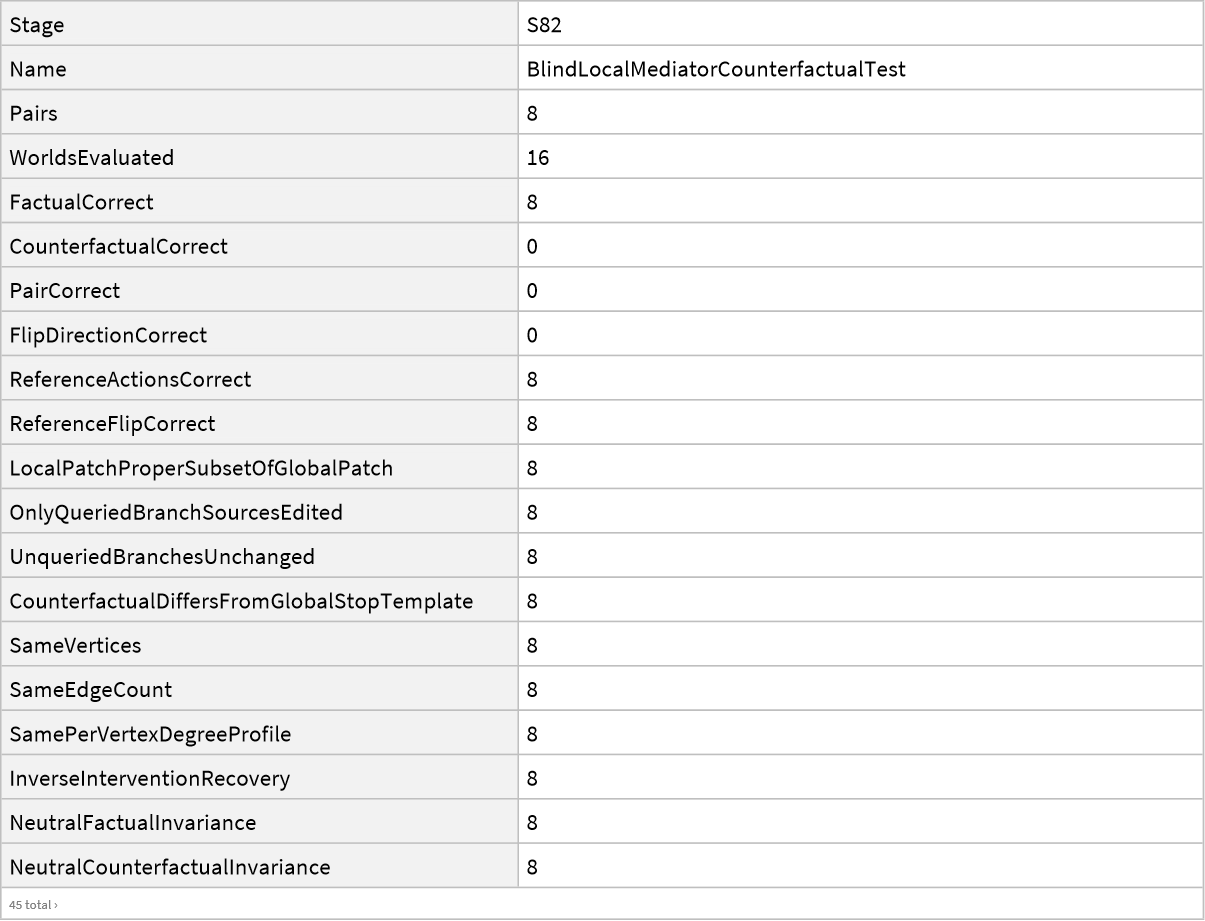

In [203]:
modelHashAfterBlind82=Hash[
Normal[frozen75D],
"SHA256",
"HexString"
];
coreHashAfterBlind82=Hash[
{
DownValues[P59],DownValues[A59],DownValues[T59],DownValues[Case59],
OwnValues[rw60],DownValues[Pack60],DownValues[SigLevels61],
DownValues[PropagationSafetyCap78],DownValues[RejectTrace78],
DownValues[DecisionStatePairsFromRejects78],DownValues[EncodeRows75],
DownValues[DiamondIn72],DownValues[DoubleDiamondIn79],DownValues[Case79]
},
"SHA256",
"HexString"
];
canonicalizerHashAfterBlind82=Hash[
{
DownValues[FindPrivateDiamond79B],
DownValues[CanonicalizePrivateDiamonds79B],
DownValues[CanonicalCase79B]
},
"SHA256",
"HexString"
];
neutralTopologyHashAfterBlind82=Hash[
{
DownValues[HierarchicalDiamondIn80],
DownValues[Case80]
},
"SHA256",
"HexString"
];
interventionHashAfterBlind82=Hash[
{
DownValues[LocalMediatorSources82],
DownValues[FullSemanticPatch82],
DownValues[LocalMediatorPatch82],
DownValues[ReferenceAction82]
},
"SHA256",
"HexString"
];
protocolHashAfterBlind82=Hash[
Normal[protocol82],
"SHA256",
"HexString"
];

modelUnchanged82=And[
SameQ[modelHashBeforeBlind82,modelHashAfterBlind82],
SameQ[modelHashAfterBlind82,expectedFrozenModelHash79A]
];
coreUnchanged82=And[
SameQ[coreHashBeforeBlind82,coreHashAfterBlind82],
SameQ[coreHashAfterBlind82,expectedMinimalKernelHash82]
];
canonicalizerUnchanged82=And[
SameQ[
canonicalizerHashBeforeBlind82,
canonicalizerHashAfterBlind82
],
SameQ[
canonicalizerHashAfterBlind82,
expectedCanonicalizerHash82
]
];
neutralTopologyUnchanged82=And[
SameQ[
neutralTopologyHashBeforeBlind82,
neutralTopologyHashAfterBlind82
],
SameQ[
neutralTopologyHashAfterBlind82,
expectedNeutralTopologyHash82
]
];
protocolUnchanged82=SameQ[
protocolHashBeforeBlind82,
protocolHashAfterBlind82
];
interventionUnchanged82=SameQ[
interventionHashBeforeBlind82,
interventionHashAfterBlind82
];

testValidityPassed82=And[
TrueQ[freezePreflightPassed82],
TrueQ[modelUnchanged82],
TrueQ[coreUnchanged82],
TrueQ[canonicalizerUnchanged82],
TrueQ[neutralTopologyUnchanged82],
TrueQ[protocolUnchanged82],
TrueQ[interventionUnchanged82],
SameQ[Length[blindCounterfactualPairs82],8],
SameQ[CountTrue82["ReferenceActionsCorrect"],8],
SameQ[CountTrue82["ReferenceFlipCorrect"],8],
SameQ[CountTrue82["LocalPatchProperSubsetOfGlobalPatch"],8],
SameQ[CountTrue82["OnlyQueriedBranchSourcesEdited"],8],
SameQ[CountTrue82["UnqueriedBranchesUnchanged"],8],
SameQ[CountTrue82["CounterfactualDiffersFromFactual"],8],
SameQ[CountTrue82["CounterfactualDiffersFromGlobalStopTemplate"],8],
SameQ[CountTrue82["SameVertices"],8],
SameQ[CountTrue82["SameEdgeCount"],8],
SameQ[CountTrue82["SamePerVertexDegreeProfile"],8],
SameQ[Counts@Lookup[blindCounterfactualPairs82,"RemovedEdges"],<|3->8|>],
SameQ[Counts@Lookup[blindCounterfactualPairs82,"AddedEdges"],<|3->8|>],
SameQ[Counts@Lookup[blindCounterfactualPairs82,"EdgeEditDistance"],<|6->8|>],
SameQ[CountTrue82["InverseInterventionRecoversFactual"],8],
SameQ[CountTrue82["NeutralFactualRecoversExact"],8],
SameQ[CountTrue82["NeutralCounterfactualRecoversExact"],8],
SameQ[blindSummary82["WorldsTerminatedNaturally"],16],
SameQ[blindSummary82["WorldsHitSafetyCap"],0]
];

blindCounterfactualPerfect82=And[
TrueQ[testValidityPassed82],
SameQ[blindSummary82["FactualCorrect"],8],
SameQ[blindSummary82["CounterfactualCorrect"],8],
SameQ[blindSummary82["PairCorrect"],8],
SameQ[blindSummary82["FlipDirectionCorrect"],8]
];

resultPayload82=<|
"Stage"->"S82",
"Name"->"BlindLocalMediatorCounterfactualTest",
"FrozenArchitectureHash"->frozenArchitectureHash82,
"PriorS81ProtocolHash"->expectedS81ProtocolHash82,
"PriorS81ResultHash"->expectedS81ResultHash82,
"ProtocolHash"->protocolHashAfterBlind82,
"Pairs"->Length[blindCounterfactualPairs82],
"WorldsEvaluated"->2 Length[blindCounterfactualPairs82],
"FactualCorrect"->blindSummary82["FactualCorrect"],
"CounterfactualCorrect"->blindSummary82["CounterfactualCorrect"],
"PairCorrect"->blindSummary82["PairCorrect"],
"FlipDirectionCorrect"->blindSummary82["FlipDirectionCorrect"],
"ReferenceActionsCorrect"->
blindSummary82["ReferenceActionsCorrect"],
"ReferenceFlipCorrect"->
blindSummary82["ReferenceFlipCorrect"],
"LocalPatchProperSubsetOfGlobalPatch"->
blindSummary82["LocalPatchProperSubsetOfGlobalPatch"],
"OnlyQueriedBranchSourcesEdited"->
blindSummary82["OnlyQueriedBranchSourcesEdited"],
"UnqueriedBranchesUnchanged"->
blindSummary82["UnqueriedBranchesUnchanged"],
"CounterfactualDiffersFromGlobalStopTemplate"->
blindSummary82["CounterfactualDiffersFromGlobalStopTemplate"],
"SameVertices"->blindSummary82["SameVertices"],
"SameEdgeCount"->blindSummary82["SameEdgeCount"],
"SamePerVertexDegreeProfile"->
blindSummary82["SamePerVertexDegreeProfile"],
"InverseInterventionRecovery"->
blindSummary82["InverseInterventionRecovery"],
"NeutralFactualInvariance"->
blindSummary82["NeutralFactualInvariance"],
"NeutralCounterfactualInvariance"->
blindSummary82["NeutralCounterfactualInvariance"],
"RemovedEdgeCounts"->blindSummary82["RemovedEdgeCounts"],
"AddedEdgeCounts"->blindSummary82["AddedEdgeCounts"],
"EdgeEditDistances"->blindSummary82["EdgeEditDistances"],
"FactualCodeSet"->blindSummary82["FactualCodeSet"],
"CounterfactualCodeSet"->blindSummary82["CounterfactualCodeSet"],
"ModelUnchanged"->modelUnchanged82,
"CoreUnchanged"->coreUnchanged82,
"CanonicalizerUnchanged"->canonicalizerUnchanged82,
"NeutralTopologyUnchanged"->neutralTopologyUnchanged82,
"InterventionImplementationHash"->
interventionHashAfterBlind82,
"InterventionUnchanged"->interventionUnchanged82,
"ProtocolUnchanged"->protocolUnchanged82,
"TestValidityPassed"->testValidityPassed82,
"BlindCounterfactualPerfect"->blindCounterfactualPerfect82
|>;

resultHash82=Hash[
Normal[resultPayload82],
"SHA256",
"HexString"
];

cert82=Join[
resultPayload82,
<|
"CounterfactualMethod"->
"BlindLocalGraphInterventionAndFrozenForwardSimulation",
"HistoricalRegressionRerun"->False,
"S81PairAuditRerun"->False,
"TrainingRun"->False,
"CandidateSearchRun"->False,
"PolicyEditApplied"->False,
"RetuningApplied"->False,
"OverallArchitectureChangedDuringS82"->False,
"InterventionTypeNovel"->True,
"FactualWorldTypeSeen"->True,
"CounterfactualHybridWorldTypeSeen"->False,
"S82IsBlindCounterfactualTest"->True,
"MayClaimBlindLocalInterventionCounterfactualGeneralization"->
blindCounterfactualPerfect82,
"MayClaimGeneralCounterfactualReasoning"->False,
"MayClaimCausalDiscovery"->False,
"TotalTraceSeconds"->blindSummary82["TotalTraceSeconds"],
"BlindResultHash"->resultHash82,
"Outcome"->Which[
!TrueQ[testValidityPassed82],
"INVALID_BLIND_COUNTERFACTUAL_TEST",
TrueQ[blindCounterfactualPerfect82],
"BLIND_LOCAL_COUNTERFACTUAL_PASS",
True,
"VALID_BLIND_LOCAL_COUNTERFACTUAL_FAILURE"
],
"SuggestedNextStage"->If[
TrueQ[blindCounterfactualPerfect82],
"S83_COUNTERFACTUAL_TOPOLOGY_COMPOSITION_TEST",
"S82A_BLIND_FAILURE_MECHANISM_AUDIT_WITHOUT_RETUNING"
]
|>
];

Dataset[{KeyTake[
cert82,
{
"Stage","Name","Pairs","WorldsEvaluated",
"FactualCorrect","CounterfactualCorrect","PairCorrect",
"FlipDirectionCorrect","ReferenceActionsCorrect",
"ReferenceFlipCorrect","LocalPatchProperSubsetOfGlobalPatch",
"OnlyQueriedBranchSourcesEdited","UnqueriedBranchesUnchanged",
"CounterfactualDiffersFromGlobalStopTemplate",
"SameVertices","SameEdgeCount","SamePerVertexDegreeProfile",
"InverseInterventionRecovery","NeutralFactualInvariance",
"NeutralCounterfactualInvariance","RemovedEdgeCounts",
"AddedEdgeCounts","EdgeEditDistances","FactualCodeSet",
"CounterfactualCodeSet","ModelUnchanged","CoreUnchanged",
"CanonicalizerUnchanged","NeutralTopologyUnchanged",
"InterventionImplementationHash","InterventionUnchanged",
"ProtocolUnchanged","TestValidityPassed",
"BlindCounterfactualPerfect","InterventionTypeNovel",
"CounterfactualHybridWorldTypeSeen","S82IsBlindCounterfactualTest",
"MayClaimBlindLocalInterventionCounterfactualGeneralization",
"MayClaimGeneralCounterfactualReasoning","MayClaimCausalDiscovery",
"TotalTraceSeconds","ProtocolHash","BlindResultHash",
"Outcome","SuggestedNextStage"
}
]}]
